# 01 — Tensor bridge and dataset export

How `ModelPart` data becomes a `torch.Tensor` (and comes back), and how to export
simulation fields as an `.npz` training dataset consumable by a `torch.utils.data.DataLoader`.

> **Prerequisites**: a compiled Kratos with `PhysicsNeMoApplication` enabled and, on the
> environment running this notebook:
>
> ```bash
> export PYTHONPATH=/path/to/Kratos/bin/Release
> export LD_LIBRARY_PATH=/path/to/Kratos/bin/Release/libs:$LD_LIBRARY_PATH
> pip install torch nvidia-physicsnemo   # optional runtime dependencies of the application
> ```
>
> Everything below runs on CPU in a few seconds; outputs are written to `./output/`.

In [1]:
from pathlib import Path

import numpy
import torch

import KratosMultiphysics as Kratos
from KratosMultiphysics.PhysicsNeMoApplication.bridges import torch_bridge
from KratosMultiphysics.PhysicsNeMoApplication.processes.export.dataset_export_process import DatasetExportProcess
from KratosMultiphysics.PhysicsNeMoApplication.training.torch_dataset import CreateNpzDataset

torch.manual_seed(0)
Path("output").mkdir(exist_ok=True)

 |  /           |                  
 ' /   __| _` | __|  _ \   __|    
 . \  |   (   | |   (   |\__ \  
_|\_\_|  \__,_|\__|\___/ ____/
           Multi-Physics 10.4."2"-physicsnemo-application-e03638205c2-Release-x86_64
           Compiled for GNU/Linux and Python3.12 with GCC-13.3
Compiled with threading and MPI support. Threading support with OpenMP.
Maximum number of threads: 2.
Running without MPI.
Importing    KratosPhysicsNeMoApplication 
 ______  _                _            ______        ______                           _ _                 _            
(_____ \| |              (_)          |  ___ \      |  ___ \         /\              | (_)           _   (_)            
 _____) ) | _  _   _  ___ _  ____  ___| |   | | ____| | _ | | ___   /  \  ____  ____ | |_  ____ ____| |_  _  ___  ____  
|  ____/| || \| | | |/___) |/ ___)/___) |   | |/ _  ) || || |/ _ \ / /\ \|  _ \|  _ \| | |/ ___) _  |  _)| |/ _ \|  _ \
| |     | | | | |_| |___ | ( (___|___ | |   | ( (/ /| || || | |_| | |

## A small model part

Ten nodes on a line, carrying a historical `VELOCITY` (vector) and `PRESSURE` (scalar).

In [2]:
model = Kratos.Model()
model_part = model.CreateModelPart("Main")
model_part.AddNodalSolutionStepVariable(Kratos.VELOCITY)
model_part.AddNodalSolutionStepVariable(Kratos.PRESSURE)
for i in range(10):
    node = model_part.CreateNewNode(i + 1, i / 9.0, 0.0, 0.0)
    node.SetSolutionStepValue(Kratos.VELOCITY, [node.X, 2.0 * node.X, 0.0])
    node.SetSolutionStepValue(Kratos.PRESSURE, node.X**2)
print(f"{model_part.NumberOfNodes()} nodes")

10 nodes


## ModelPart → torch, zero-copy

`KratosTensorToTorch` wraps the tensor adaptor's staging buffer without copying:
mutating the torch tensor mutates the adaptor's `.data` view. (`CollectData()` /
`StoreData()` move data across the last hop to the actual — non-contiguous — Kratos
entity storage.)

In [3]:
ta = Kratos.TensorAdaptors.HistoricalVariableTensorAdaptor(model_part.Nodes, Kratos.VELOCITY)
ta.CollectData()
velocity = torch_bridge.KratosTensorToTorch(ta)
print("shape:", tuple(velocity.shape), "dtype:", velocity.dtype)

velocity[0, 0] = -42.0  # zero-copy: this writes into the adaptor's buffer
print("adaptor sees the mutation:", ta.data[0, 0])

shape: (10, 3) dtype: torch.float64
adaptor sees the mutation: -42.0


## torch → ModelPart

`TorchToKratosTensor` copies the values in (the tensor may live on a GPU or in an
autograd graph) and calls `StoreData()` so they reach the nodes.

In [4]:
torch_bridge.TorchToKratosTensor(2.0 * velocity, ta)
print("node 1 VELOCITY_X after write-back:", model_part.GetNode(1).GetSolutionStepValue(Kratos.VELOCITY_X))

node 1 VELOCITY_X after write-back: -84.0


## Exporting a training dataset

`DatasetExportProcess` writes one `.npz` per sampled step — keys are
`<VARIABLE>__<location>` plus `TIME`/`STEP`. It has **no ML dependency at all**, so it
runs on any Kratos installation (e.g. inside an HPC job).

In [5]:
settings = Kratos.Parameters("""{
    "model_part_name" : "Main",
    "list_of_fields"  : [
        { "variable_name" : "VELOCITY", "data_location" : "node_historical" },
        { "variable_name" : "PRESSURE", "data_location" : "node_historical" }
    ],
    "output_path"     : "output/dataset",
    "output_interval" : 1
}""")
export = DatasetExportProcess(model, settings)
export.ExecuteInitialize()

for step in range(1, 6):
    model_part.ProcessInfo[Kratos.STEP] = step
    model_part.ProcessInfo[Kratos.TIME] = 0.1 * step
    for node in model_part.Nodes:  # stand-in for an actual solve
        node.SetSolutionStepValue(Kratos.PRESSURE, node.X**2 + 0.1 * step)
    export.ExecuteFinalizeSolutionStep()

sorted(p.name for p in Path("output/dataset").glob("*.npz"))

['sample_1.npz',
 'sample_2.npz',
 'sample_3.npz',
 'sample_4.npz',
 'sample_5.npz']

### What just moved

The ten nodes the bridge has been reading and writing, rendered with pyvista: the `VELOCITY_X` values written back through the adaptor and the `PRESSURE` of the last exported step.

/home/vicente/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


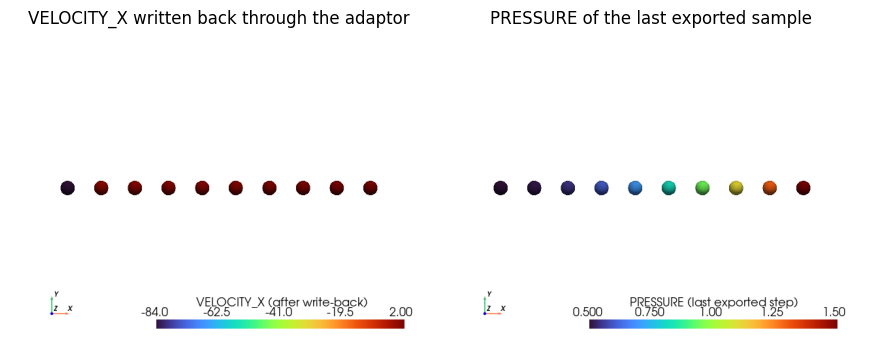

In [6]:
import pyvista as pv
from KratosMultiphysics import pyvista_utilities as pv_utils

def render_points(points, values, title, cmap="turbo", clim=None, point_size=14, view="iso"):
    """Off-screen pyvista render of a point cloud coloured by a scalar (numpy image)."""
    cloud = pv.PolyData(numpy.asarray(points, dtype=float))
    cloud["value"] = numpy.asarray(values, dtype=float).ravel()
    plotter = pv.Plotter(off_screen=True, window_size=(640, 480))
    plotter.add_points(cloud, scalars="value", cmap=cmap, clim=clim, point_size=point_size,
                       render_points_as_spheres=True, scalar_bar_args={"title": title})
    plotter.add_axes()
    plotter.view_xy() if view == "xy" else plotter.view_isometric()
    return plotter.screenshot(None)
import matplotlib.pyplot as plt

points = numpy.array([[n.X, n.Y, n.Z] for n in model_part.Nodes])
vx = [n.GetSolutionStepValue(Kratos.VELOCITY_X) for n in model_part.Nodes]
pressure = [n.GetSolutionStepValue(Kratos.PRESSURE) for n in model_part.Nodes]
img_v = render_points(points, vx, "VELOCITY_X (after write-back)", view="xy", point_size=22)
img_p = render_points(points, pressure, "PRESSURE (last exported step)", view="xy", point_size=22)
fig, axes = plt.subplots(1, 2, figsize=(8.8, 4.0))
for ax, (img, title) in zip(numpy.atleast_1d(axes), [(img_v, 'VELOCITY_X written back through the adaptor'), (img_p, 'PRESSURE of the last exported sample')]):
    ax.imshow(img); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.savefig('output/nodes.png', dpi=120, bbox_inches="tight"); plt.show()


## Training on the export

`CreateNpzDataset` exposes the directory as a `torch.utils.data.Dataset`, with the same
per-entity `(n, width)` concatenated layout `InferenceProcess` uses at deployment time.

In [7]:
dataset = CreateNpzDataset("output/dataset",
                           input_keys=["VELOCITY__node_historical"],
                           output_keys=["PRESSURE__node_historical"])
loader = torch.utils.data.DataLoader(dataset, batch_size=2)
for inputs, targets in loader:
    print("batch:", tuple(inputs.shape), "->", tuple(targets.shape))

batch: (2, 10, 3) -> (2, 10, 1)
batch: (2, 10, 3) -> (2, 10, 1)
batch: (1, 10, 3) -> (1, 10, 1)
